# Waterfilling Algorithm Testing and Visualization
This notebook tests the waterfilling algorithm across different network contexts: Opera, Shale, Sirius, and generic timeslots. It also explores diurnal traffic patterns, latency scenarios, and Genetic Algorithm optimized topologies.

In [13]:
import numpy as np
import random
import matplotlib.pyplot as plt
import os
from Waterfilling_Alg import waterfilling
from Shale_Alg import RR2, RR2_path
from Common_Alg import generate_random_latin_square
from Sirius import generate_full_system
from AI_Topology import evolve_topology

if not os.path.exists('plots'):
    os.makedirs('plots')

In [14]:
def visualize_waterfilling(channels, total_power, title="Waterfilling Results", filename=None):
    """
    Visualizes the waterfilling power allocation using a stacked bar chart.
    Highlights bottlenecks (channels with 0 allocated power due to high noise).
    Saves the image if a filename is provided.
    """
    channels = np.array(channels)
    
    # Handle 2D case (multiple timeslots)
    if channels.ndim == 2:
        num_timeslots = channels.shape[0]
        # Handle scalar power vs per-timeslot power
        if np.isscalar(total_power):
            powers = [total_power] * num_timeslots
        else:
            powers = total_power
            
        for t in range(num_timeslots):
            # Recursively call for each timeslot
            ts_filename = f"plots/{filename}_ts{t}.png" if filename else None
            visualize_waterfilling(channels[t], powers[t], title=f"{title} - Timeslot {t}", filename=ts_filename)
        return

    # --- 1D Logic ---
    allocation = waterfilling(channels, total_power)
    n = len(channels)
    indices = np.arange(n)
    
    active_mask = allocation > 1e-9
    bottleneck_mask = ~active_mask
    
    # Calculate Water Level (Noise + Allocated Power) for active channels
    if np.any(active_mask):
        # All active channels should sum to the same level
        water_levels = channels[active_mask] + allocation[active_mask]
        water_level = np.mean(water_levels) 
    else:
        water_level = 0 

    plt.figure(figsize=(10, 6))
    
    # 1. Plot Active Noise (Gray)
    if np.any(active_mask):
        plt.bar(indices[active_mask], channels[active_mask], 
                label='Noise (Active)', color='lightgray', edgecolor='black')
        
    # 2. Plot Bottleneck Noise (Red/Salmon) - These are the bottlenecks!
    if np.any(bottleneck_mask):
        plt.bar(indices[bottleneck_mask], channels[bottleneck_mask], 
                label='Noise (Bottleneck)', color='salmon', edgecolor='black', hatch='//')

    # 3. Plot Allocated Power (Blue)
    if np.any(active_mask):
        plt.bar(indices[active_mask], allocation[active_mask], bottom=channels[active_mask], 
                label='Allocated Power', color='skyblue', edgecolor='black')
    
    # 4. Water Level Line
    plt.axhline(y=water_level, color='blue', linestyle='--', linewidth=2, label=f'Water Level ({water_level:.2f})')
    
    plt.xlabel('Channel / Link Index')
    plt.ylabel('Power / Noise Level')
    plt.title(title)
    plt.xticks(indices, [f'Ch {i}' for i in indices])
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    if filename:
        plt.savefig(filename if filename.startswith('plots/') else f"plots/{filename}")
        print(f"Saved plot to {filename}")
    plt.show()

## 1. Diurnal Traffic Patterns
Modeling power budget based on a day/night cycle.

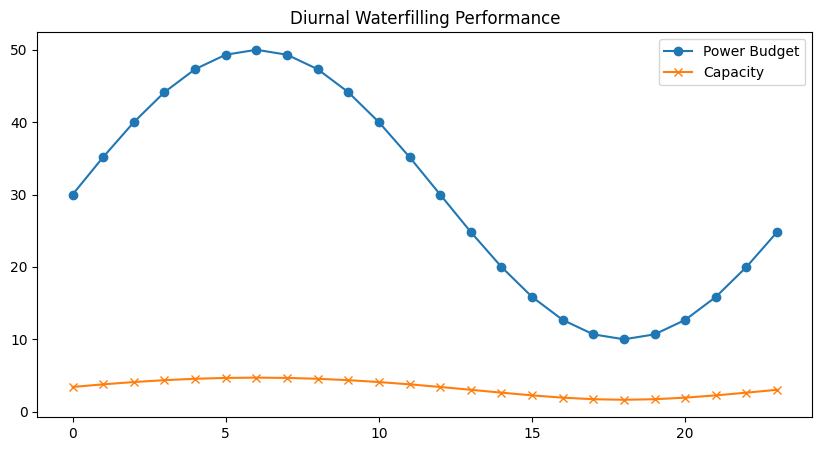

Saved plot to diurnal_day.png


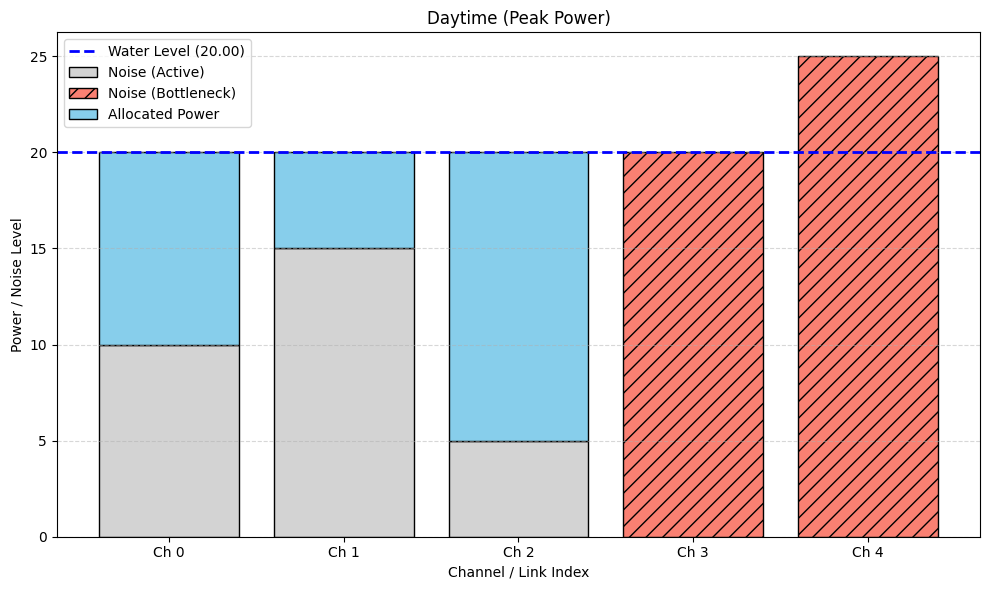

Saved plot to diurnal_night.png


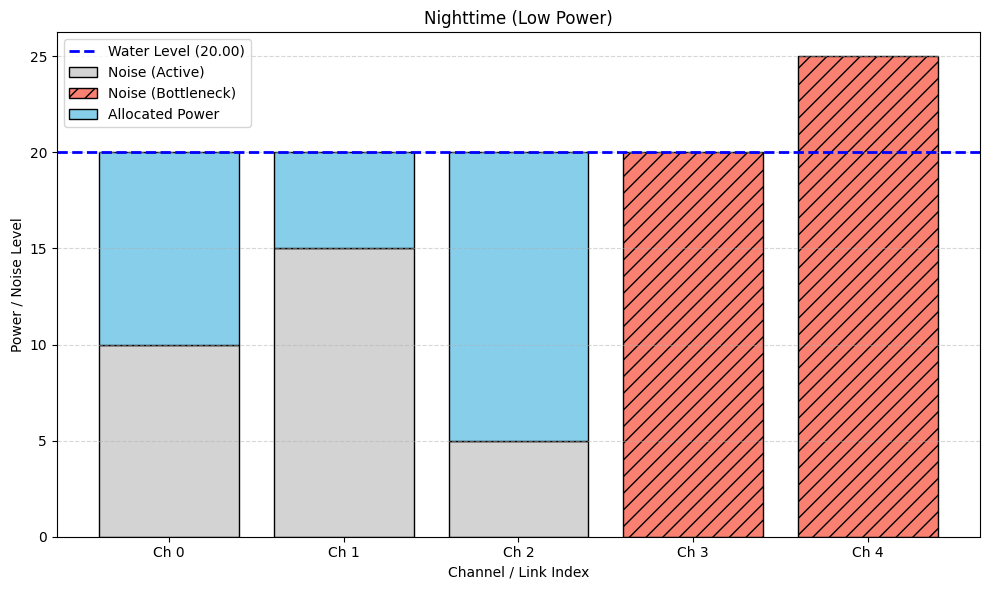

In [15]:
def generate_diurnal_power(num_timeslots, baseline=30, amplitude=20):
    t = np.arange(num_timeslots)
    return baseline + amplitude * np.sin(2 * np.pi * t / num_timeslots)

num_timeslots = 24
noise = [10, 15, 5, 20, 25]
power_budgets = generate_diurnal_power(num_timeslots)
allocations = waterfilling([noise]*num_timeslots, power_budgets)

capacities = [np.sum(np.log2(1 + allocations[t]/noise)) for t in range(num_timeslots)]

plt.figure(figsize=(10, 5))
plt.plot(power_budgets, label='Power Budget', marker='o')
plt.plot(capacities, label='Capacity', marker='x')
plt.title("Diurnal Waterfilling Performance")
plt.legend()
plt.savefig("plots/diurnal_performance.png")
plt.show()

visualize_waterfilling(noise, power_budgets[12], title="Daytime (Peak Power)", filename="diurnal_day.png")
visualize_waterfilling(noise, power_budgets[0], title="Nighttime (Low Power)", filename="diurnal_night.png")

## 2. Latency Scenarios (Low vs High)

Saved plot to opera_low_latency


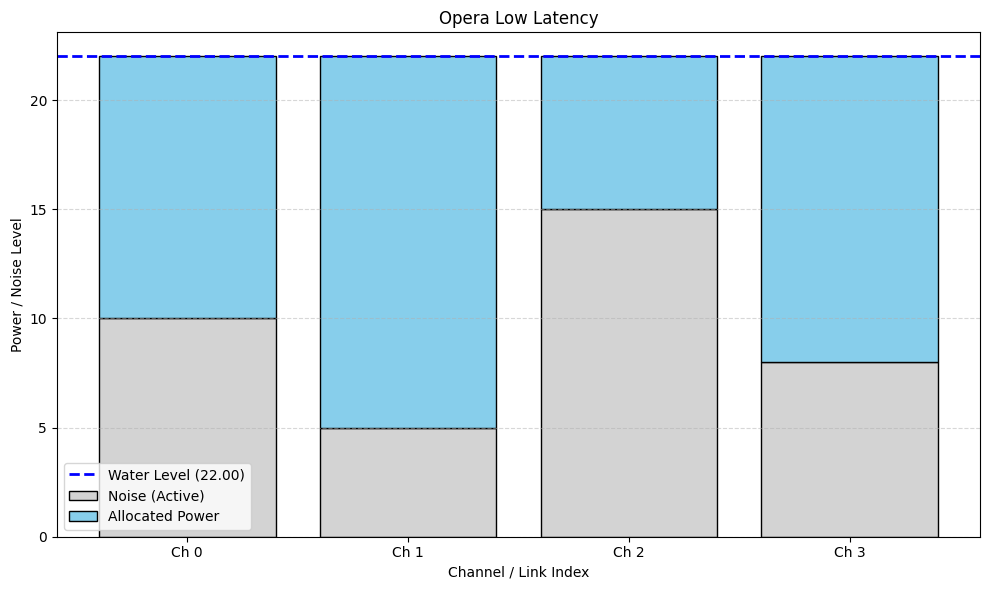

Saved plot to opera_high_latency


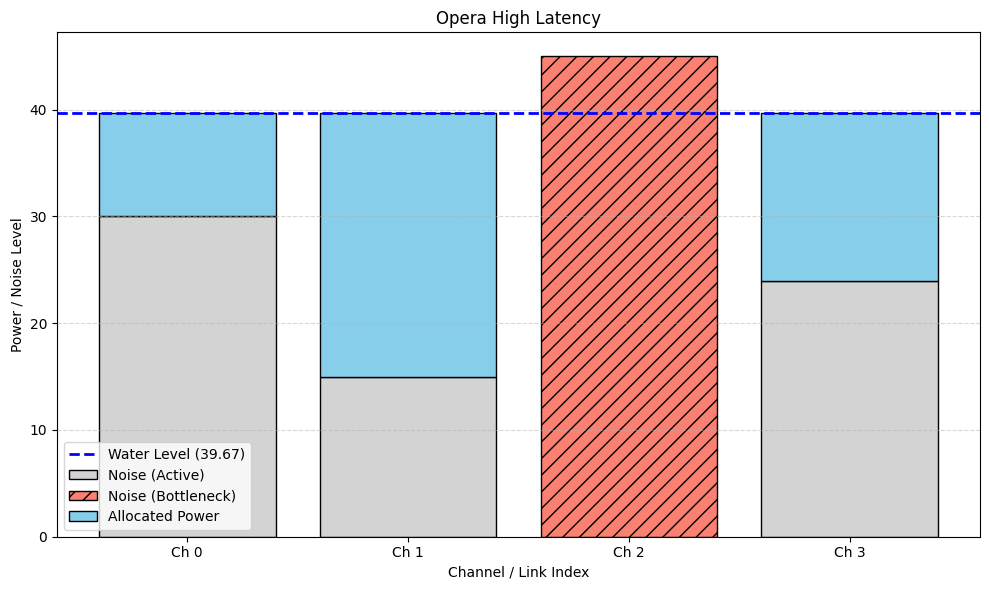

Saved plot to shale_low_latency


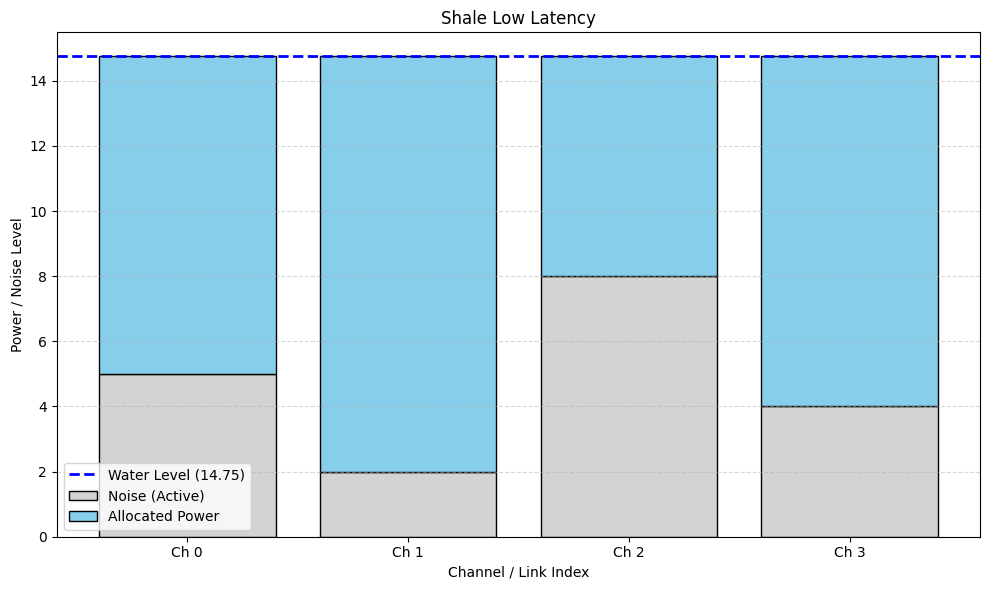

Saved plot to shale_high_latency


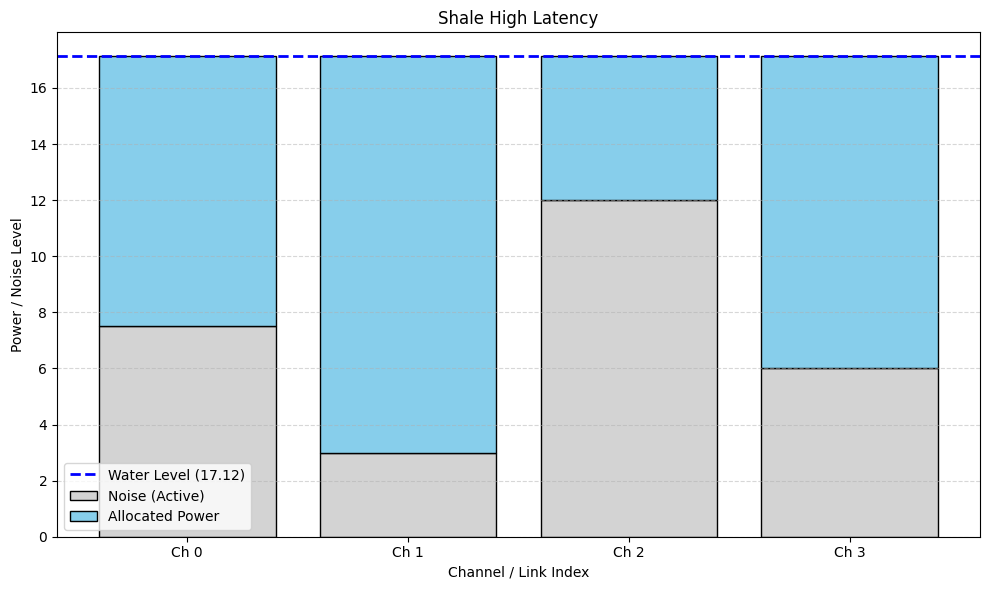

In [16]:
def run_latency_scenarios():
    # Opera
    base_noise = [10, 5, 15, 8]
    visualize_waterfilling(base_noise, 50, "Opera Low Latency", "opera_low_latency")
    visualize_waterfilling([n*3 for n in base_noise], 50, "Opera High Latency", "opera_high_latency")
    
    # Shale
    shale_noise = [5, 2, 8, 4]
    visualize_waterfilling(shale_noise, 40, "Shale Low Latency", "shale_low_latency")
    visualize_waterfilling([n*1.5 for n in shale_noise], 40, "Shale High Latency", "shale_high_latency")

run_latency_scenarios()

## 3. Genetic Algorithm Waterfilling (Node-based Timeslots)

Evolving GA Topology for Waterfilling Test...
AI Evolving Topology (PyGAD) (N=6, D=2)...
Evolution Complete. Best Fitness: 0.3261
Best ASPL: 2.0667
Saved plot to genetic_node_0


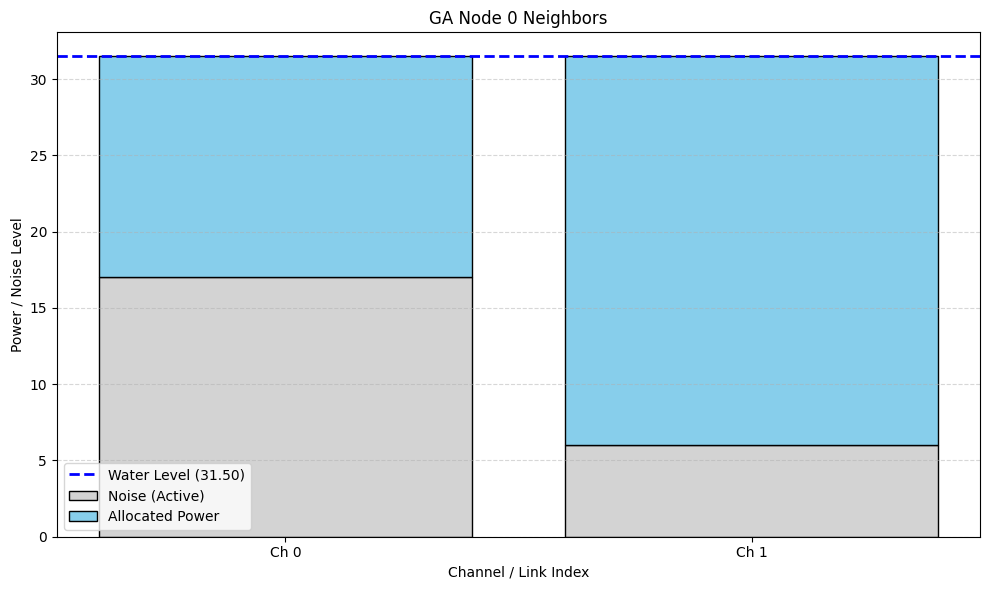

Saved plot to genetic_node_1


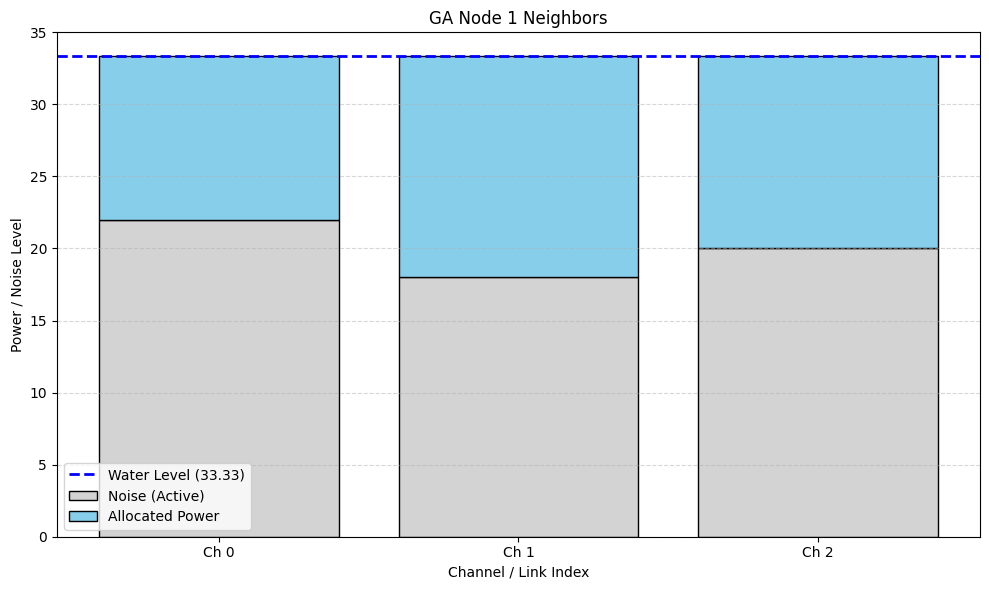

Saved plot to genetic_node_2


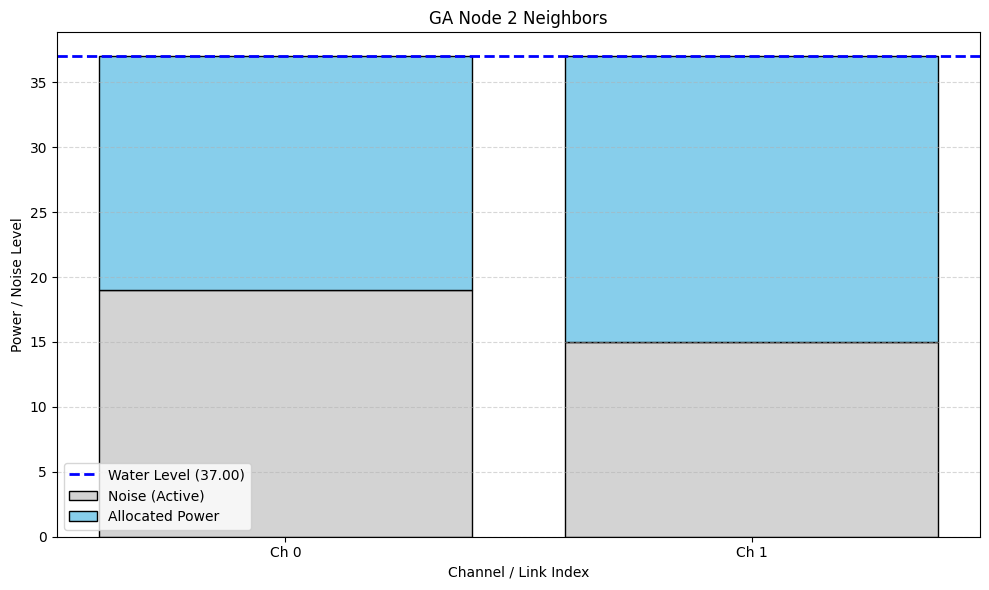

Saved plot to genetic_node_3


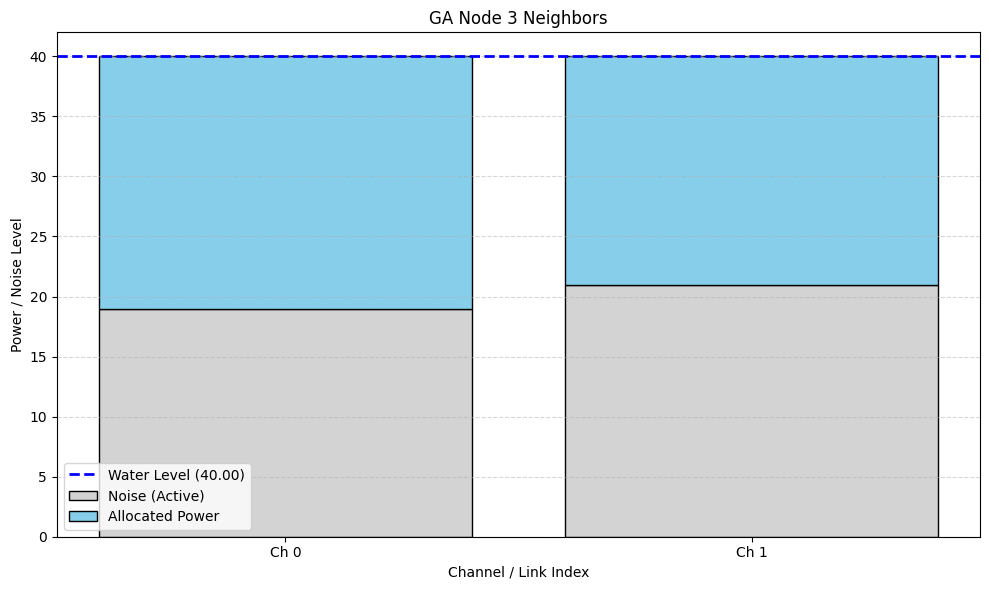

Saved plot to genetic_node_4


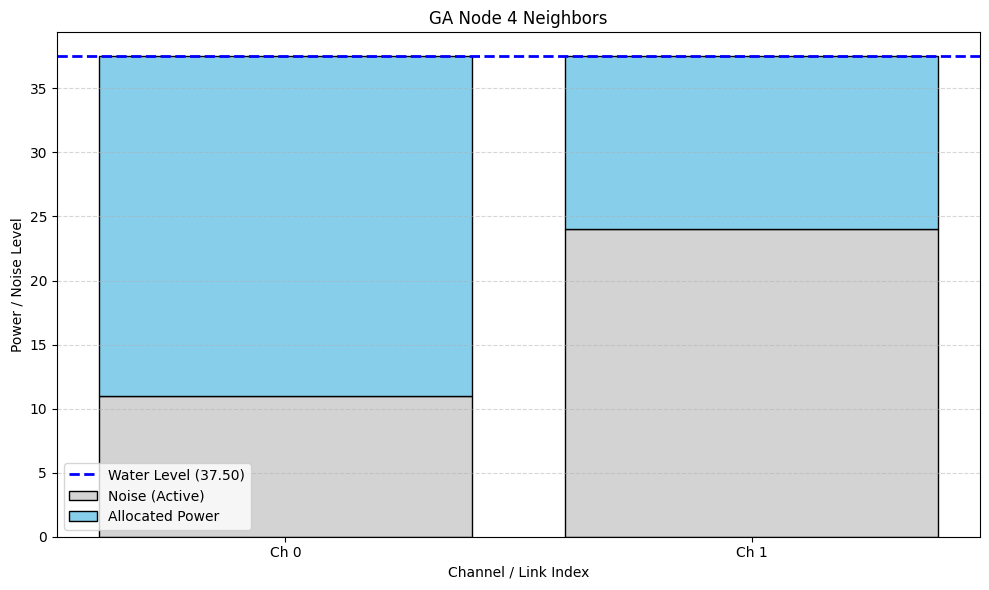

Saved plot to genetic_node_5


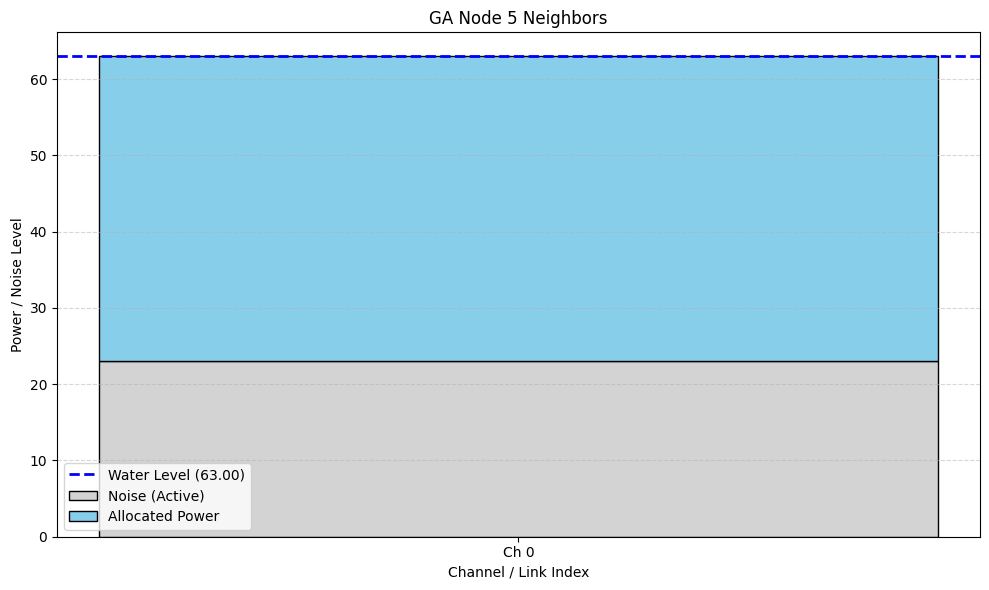

In [17]:
print("Evolving GA Topology for Waterfilling Test...")
num_nodes = 6
best_adj = evolve_topology(num_nodes, 2, population_size=10, generations=20)

for i in range(num_nodes):
    num_links = len(best_adj[i])
    node_noise = [random.randint(5, 25) for _ in range(num_links)]
    visualize_waterfilling(node_noise, 40, f"GA Node {i} Neighbors", f"genetic_node_{i}")

## 4. Sirius and Others

Saved plot to plots/sirius_wf_ts0.png


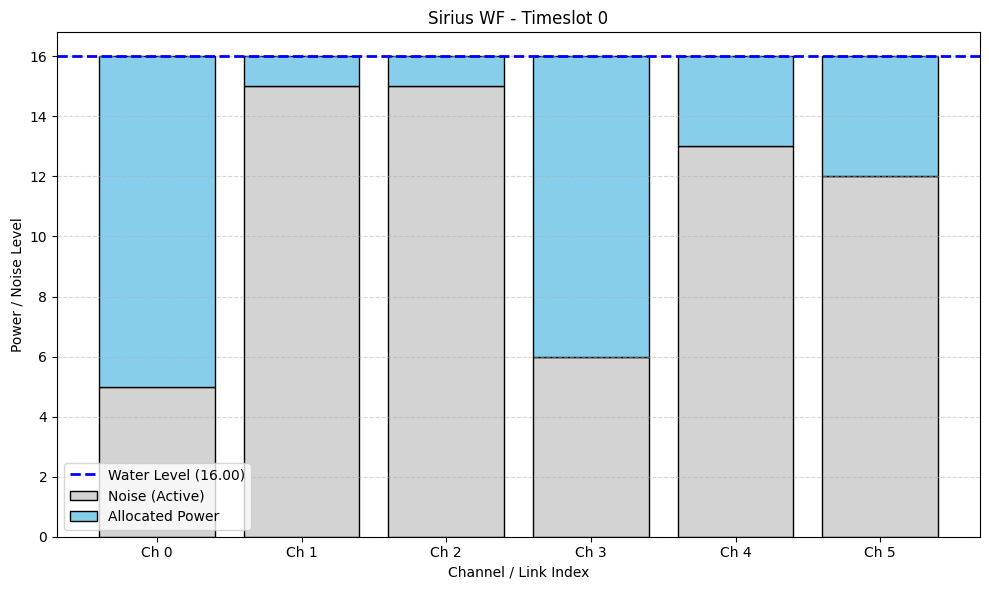

Saved plot to plots/sirius_wf_ts1.png


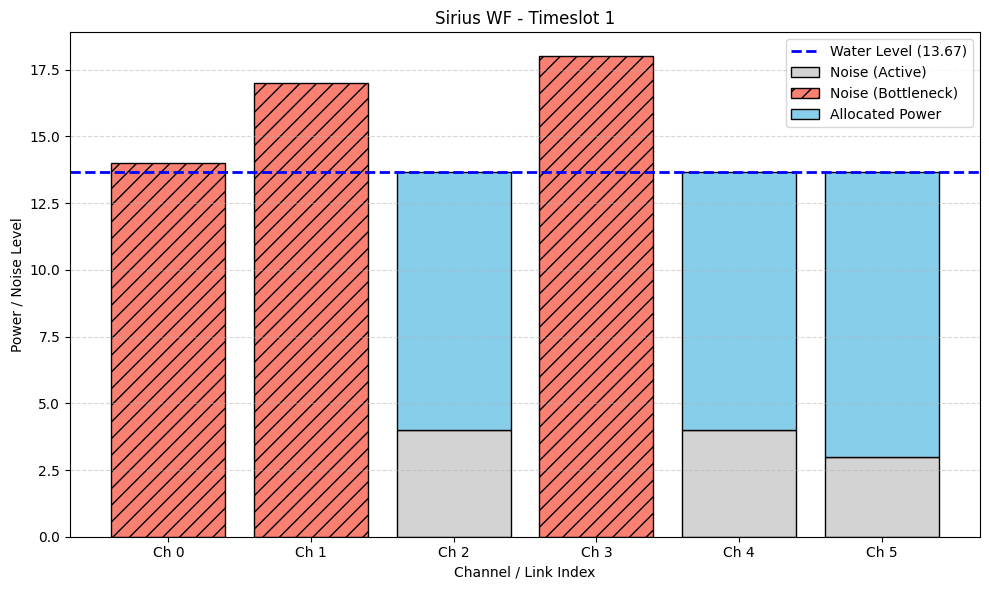

Saved plot to plots/sirius_wf_ts2.png


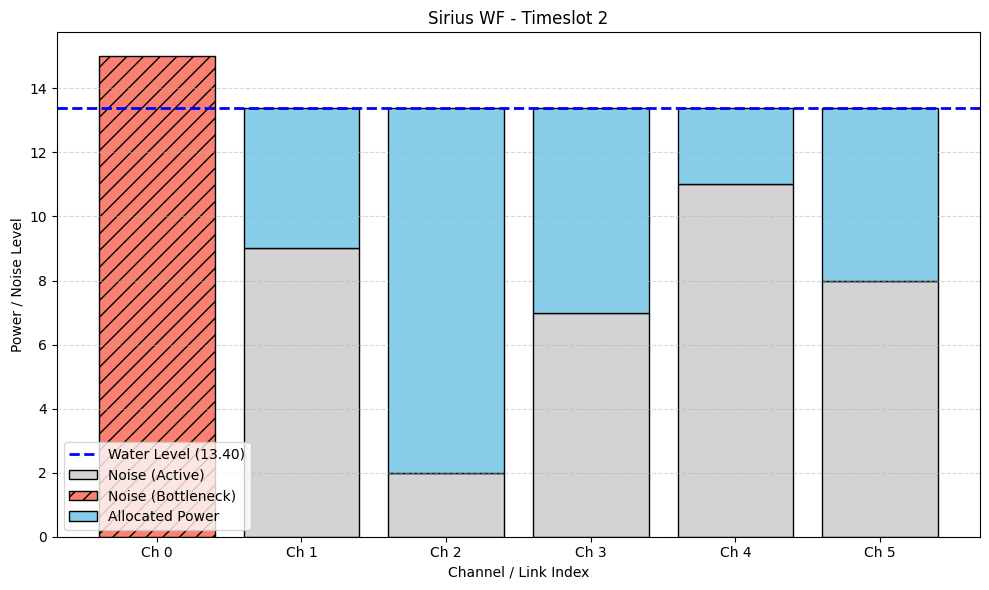

In [18]:
wavelengths = 3; ports = 2; nodes = 6
As, Ws, P_mat = generate_full_system(wavelengths, ports, nodes)
random.seed(100)
sirius_noise = [[random.randint(1, 20) for _ in range(nodes)] for _ in range(len(Ws))]
visualize_waterfilling(sirius_noise, 30, "Sirius WF", "sirius_wf")